# Phase 2: Data Preprocessing & Feature Engineering

This notebook handles the cleaning and transformation of the Metro Interstate Traffic Volume dataset. We will extract time-based features and encode weather categories to prepare the data for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
import joblib

# Set visual style
sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
df = pd.read_csv('../dataset/Metro_Interstate_Traffic_Volume.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 2. Basic Cleaning
Check for missing values and duplicates.

In [3]:
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Missing values:
 holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Duplicate rows: 17
Shape after removing duplicates: (48187, 9)


## 3. Feature Engineering
Converting `date_time` into numerical features that the model can interpret.

In [4]:
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract time features
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Define rush hours (typical 7-9 AM and 4-6 PM)
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month,weekday,is_weekend,is_rush_hour
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,1,0,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,1,0,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,1,0,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,1,0,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,1,0,0


## 4. Encoding Categorical Data
The `weather_main` column is text. We need to convert it to numbers using Label Encoding.

In [5]:
le_weather = LabelEncoder()
df['weather_main_enc'] = le_weather.fit_transform(df['weather_main'])

# Save the encoder to use later in the API
os.makedirs('../models', exist_ok=True)
joblib.dump(le_weather, '../models/weather_encoder.joblib')

print("Weather categories:", le_weather.classes_)

Weather categories: ['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']


## 5. Visualizing the Patterns
Let's see the average traffic volume by hour to confirm our 'rush hour' assumption.

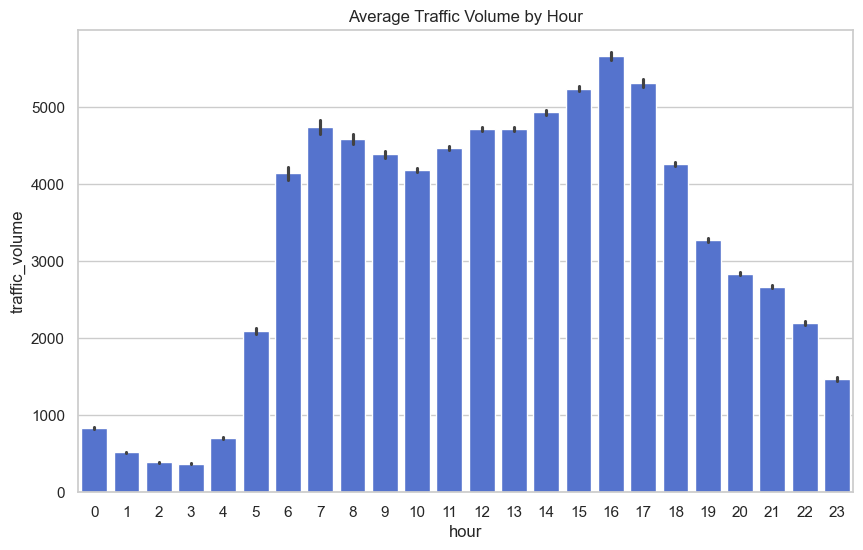

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='hour', y='traffic_volume', color='royalblue')
plt.title('Average Traffic Volume by Hour')
plt.show()

## 6. Saving Processed Data
We will save this version to be used by the training script.

In [7]:
os.makedirs('../dataset/processed', exist_ok=True)

# Select only the features we'll use for training
features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main_enc', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'is_rush_hour', 'traffic_volume']

df[features].to_csv('../dataset/processed/cleaned_traffic_data.csv', index=False)
print("Success! Cleaned data saved to dataset/processed/cleaned_traffic_data.csv")

Success! Cleaned data saved to dataset/processed/cleaned_traffic_data.csv
